In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('tabela_final.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 8 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Ano_do_Censo                             4009 non-null   int64  
 1   Nome_do_Municipio                        4009 non-null   object 
 2   Codigo_da_Escola                         4009 non-null   int64  
 3   Nome_da_Escola                           4009 non-null   object 
 4   Quantidade_de_Matriculados_Ensino_Medio  4009 non-null   float64
 5   Aprovacao_EM_Total                       4009 non-null   float64
 6   Reprovacao_EM_Total                      4009 non-null   float64
 7   Abandono_EM_Total                        4009 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 250.7+ KB


In [5]:
#checando se há valores nulos
df.isna().sum()

,0
Ano_do_Censo,0
Nome_do_Municipio,0
Codigo_da_Escola,0
Nome_da_Escola,0
Quantidade_de_Matriculados_Ensino_Medio,0
Aprovacao_EM_Total,0
Reprovacao_EM_Total,0
Abandono_EM_Total,0


In [6]:
#checando se há duplicatas
df.duplicated().sum()

np.int64(0)

In [7]:
#checando os valores únicos
df['Ano_do_Censo'].unique()


array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2015, 2016, 2025])

In [ ]:
#checando se há linhas duplicadas
df.duplicated(
    subset=['Codigo_da_Escola', 'Ano_do_Censo']
).sum()

np.int64(0)

In [3]:
df.describe()

,Ano_do_Censo,Codigo_da_Escola,Quantidade_de_Matriculados_Ensino_Medio,Aprovacao_EM_Total,Reprovacao_EM_Total,Abandono_EM_Total
count,4009.000000,4.009000e+03,4009.000000,4009.000000,4009.000000,4009.000000
mean,2020.007234,3.309524e+07,513.982040,77.664405,14.790422,7.545173
std,3.165621,5.549851e+04,520.913534,13.176567,9.987367,8.331654
min,2015.000000,3.305188e+07,2.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.307159e+07,162.000000,68.500000,7.200000,0.700000
50%,2020.000000,3.308643e+07,294.000000,77.900000,14.100000,5.200000
75%,2023.000000,3.310464e+07,671.000000,87.600000,20.800000,11.500000
max,2025.000000,3.355823e+07,2805.000000,100.000000,80.600000,100.000000


##Gráficos e outliers

In [8]:
abandono_municipio = (
    df.groupby('Nome_do_Municipio')['Abandono_EM_Total']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)



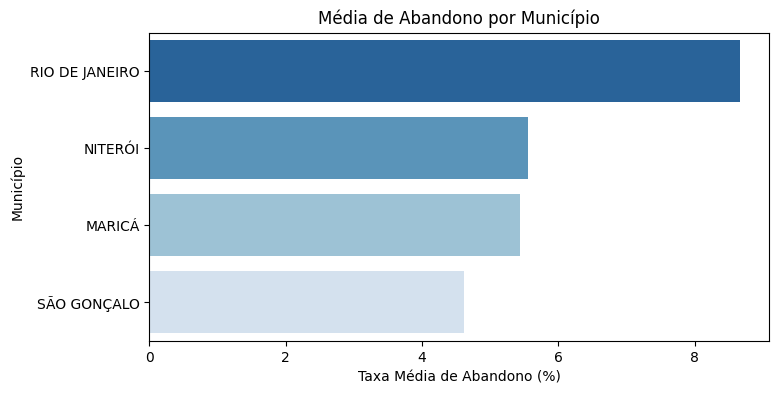

In [ ]:
#gráfico de média de abandono por município
plt.figure(figsize=(8, 4))
sns.barplot(
    data=abandono_municipio,
    y='Nome_do_Municipio',
    x='Abandono_EM_Total',
    hue='Nome_do_Municipio',
    palette='Blues_r',
    legend=False)
plt.title('Média de Abandono por Município')
plt.xlabel('Taxa Média de Abandono (%)')
plt.ylabel('Município')
plt.show()

In [ ]:
abandono_por_ano = (
    df.groupby('Ano_do_Censo')['Abandono_EM_Total']
      .mean()
      .reset_index()
)
display(abandono_por_ano)

,Ano_do_Censo,Abandono_EM_Total
0,2015,7.714601
1,2016,13.020000
2,2017,7.467751
3,2018,8.020811
4,2019,10.891086
5,2020,0.602479
6,2021,2.939118
7,2022,9.836364
8,2023,8.336639
9,2024,8.182337


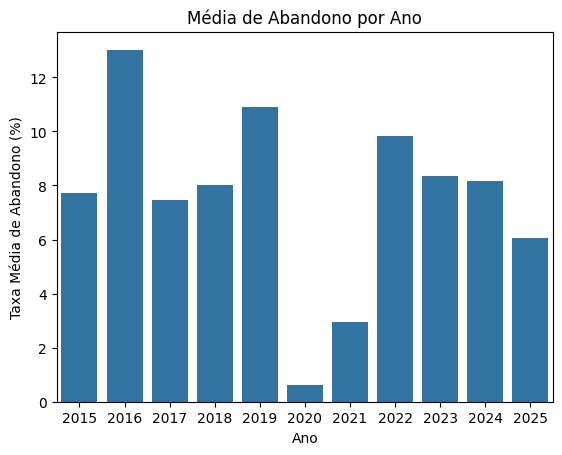

In [ ]:
#média de abandono por ano
sns.barplot(abandono_por_ano, x='Ano_do_Censo', y='Abandono_EM_Total' )
plt.title('Média de Abandono por Ano')
plt.xlabel('Ano')
plt.ylabel('Taxa Média de Abandono (%)')
plt.show()

In [ ]:
aprovacao_por_ano = (
    df.groupby('Ano_do_Censo')['Aprovacao_EM_Total']
      .mean()
      .reset_index()
)
display(aprovacao_por_ano)

,Ano_do_Censo,Aprovacao_EM_Total
0,2015,75.681818
1,2016,66.609167
2,2017,74.187534
3,2018,73.178378
4,2019,72.383287
5,2020,88.072727
6,2021,90.367218
7,2022,73.779339
8,2023,75.171350
9,2024,75.929076


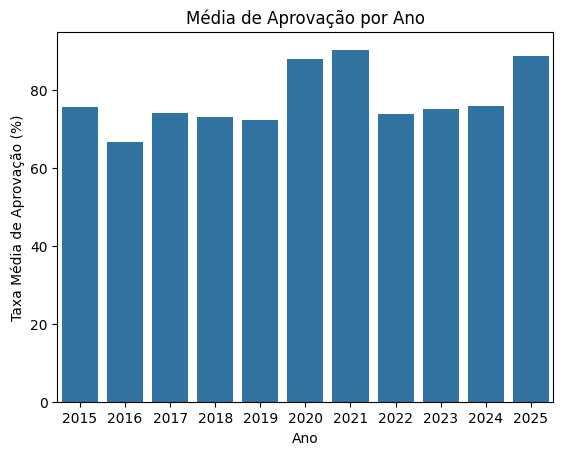

In [ ]:
#média de aprovação por ano
sns.barplot(aprovacao_por_ano, x='Ano_do_Censo', y='Aprovacao_EM_Total' )
plt.title('Média de Aprovação por Ano')
plt.xlabel('Ano')
plt.ylabel('Taxa Média de Aprovação (%)')
plt.show()

In [ ]:
#checando quantos registros temos por município
df['Nome_do_Municipio'].value_counts()

,count
Nome_do_Municipio,
RIO DE JANEIRO,2795
SÃO GONÇALO,729
NITERÓI,382
MARICÁ,103


In [ ]:
reprovacao_por_ano = (
    df.groupby('Ano_do_Censo')['Reprovacao_EM_Total']
      .mean()
      .reset_index()
)
display(reprovacao_por_ano)

,Ano_do_Censo,Reprovacao_EM_Total
0,2015,16.603581
1,2016,20.370833
2,2017,18.344715
3,2018,18.800811
4,2019,16.725627
5,2020,11.324793
6,2021,6.693664
7,2022,16.384298
8,2023,16.492011
9,2024,15.888587


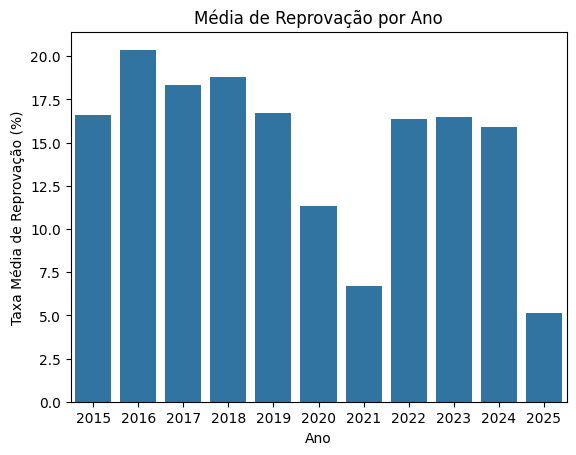

In [ ]:
#média de aprovação por ano
sns.barplot(reprovacao_por_ano, x='Ano_do_Censo', y='Reprovacao_EM_Total' )
plt.title('Média de Reprovação por Ano')
plt.xlabel('Ano')
plt.ylabel('Taxa Média de Reprovação (%)')
plt.show()

##Regressão Linear

Multicolinearidade - As 3 colunas somadas, resultam em 100%

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler # Nova biblioteca para padronização
from sklearn.metrics import mean_squared_error, r2_score


# 2. Atualizando as Variáveis Independentes (X)
# Agora incluímos os matriculados
X = df[['Aprovacao_EM_Total', 'Reprovacao_EM_Total', 'Quantidade_de_Matriculados_Ensino_Medio']]
y = df['Abandono_EM_Total']

# 3. Dividindo em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Padronizando as Escalas (Passo Crucial Novo)
# Isso transforma os dados para que tenham média 0 e desvio padrão 1,
# impedindo que os "1500 matriculados" esmaguem os "25 reprovados" no cálculo.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Usamos apenas 'transform' no teste para não vazar dados

# 5. Treinando o Modelo com os dados padronizados
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# 6. Fazendo previsões e avaliando
y_pred = modelo.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

# 7. Analisando o peso de cada fator
print("\nImpacto de cada variável (Coeficientes Padronizados):")
for var, coef in zip(X.columns, modelo.coef_):
    print(f"{var}: {coef:.4f}")

Coeficiente de Determinação (R²): 1.0000
Erro Quadrático Médio (MSE): 0.0000

Impacto de cada variável (Coeficientes Padronizados):
Aprovacao_EM_Total: -13.1713
Reprovacao_EM_Total: -9.9693
Quantidade_de_Matriculados_Ensino_Medio: 0.0000


In [30]:
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Ano_do_Censo                             4009 non-null   int64  
 1   Codigo_da_Escola                         4009 non-null   int64  
 2   Nome_da_Escola                           4009 non-null   object 
 3   Quantidade_de_Matriculados_Ensino_Medio  4009 non-null   float64
 4   Aprovacao_EM_Total                       4009 non-null   float64
 5   Reprovacao_EM_Total                      4009 non-null   float64
 6   Abandono_EM_Total                        4009 non-null   float64
 7   Nome_do_Municipio_MARICÁ                 4009 non-null   bool   
 8   Nome_do_Municipio_NITERÓI                4009 non-null   bool   
 9   Nome_do_Municipio_SÃO GONÇALO            4009 non-null   bool   
dtypes: bool(3), float64(4), int64(2), object(1)
memo

In [26]:
# 2. Codificando as cidades (One-Hot Encoding)
df_codificado = pd.get_dummies(df, columns=['Nome_do_Municipio'])

Regressão Linear com todos os anos incluídos

In [27]:
df_codificado = df_codificado.drop(columns=['Nome_do_Municipio_RIO DE JANEIRO'])

# 3. Separando as variáveis (O Pulo do Gato)
# Vamos DROPAR (remover) tudo o que não ajuda a prever o abandono no X
colunas_para_remover = ['Codigo_da_Escola', 'Nome_da_Escola', 'Abandono_EM_Total', 'Aprovacao_EM_Total', 'Reprovacao_EM_Total']

# O X terá apenas: ano_censo, matriculados e as cidades codificadas
X = df_codificado.drop(columns=colunas_para_remover)
y = df_codificado['Abandono_EM_Total']

# 4. Dividindo em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Padronizando as Escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Treinando o Modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# 7. Avaliando o Modelo com RMSE
y_pred = modelo.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Tirando a raiz quadrada do MSE

print("=== AVALIAÇÃO DO MODELO ===")
print(f"R² (Capacidade de explicação): {r2:.4f}")
print(f"RMSE (Margem de erro na vida real): {rmse:.4f} pontos de abandono\n")


# 8. Impacto das Variáveis
print("=== IMPACTO DE CADA VARIÁVEL (Coeficientes Padronizados) ===")
for var, coef in zip(X.columns, modelo.coef_):
    print(f"{var}: {coef:.4f}")

=== AVALIAÇÃO DO MODELO ===
R² (Capacidade de explicação): 0.1365
RMSE (Margem de erro na vida real): 7.5361 pontos de abandono

=== IMPACTO DE CADA VARIÁVEL (Coeficientes Padronizados) ===
Ano_do_Censo: -0.8297
Quantidade_de_Matriculados_Ensino_Medio: -1.9708
Nome_do_Municipio_MARICÁ: -0.4544
Nome_do_Municipio_NITERÓI: -1.1355
Nome_do_Municipio_SÃO GONÇALO: -1.9286


Regressão Linear sem os outliers 2020 e 2021

In [16]:

# O FILTRO: Removendo 2020 e 2021
# O símbolo '~' significa "NÃO". Ou seja: "Filtre onde o ano NÃO está na lista [2020, 2021]"
df_limpo = df[~df['Ano_do_Censo'].isin([2020, 2021])]

print(f"Total de registros antes: {len(df)}")
print(f"Total de registros após o filtro: {len(df_limpo)}\n")



df_codificado = pd.get_dummies(df_limpo, columns=['Nome_do_Municipio'])

if 'Nome_do_Municipio_RIO DE JANEIRO' in df_codificado.columns:
    df_codificado = df_codificado.drop(columns=['Nome_do_Municipio_RIO DE JANEIRO'])


# colunas_para_remover = ['Codigo_da_Escola', 'abandono']
X = df_codificado.drop(columns=colunas_para_remover)
y = df_codificado['Abandono_EM_Total']


# 5. Dividindo em Treino e Teste e Padronizando Escalas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 6. Treinando o Modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)


# 7. Avaliando o Modelo com RMSE
y_pred = modelo.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Tirando a raiz quadrada do MSE

print("=== AVALIAÇÃO DO MODELO ===")
print(f"R² (Capacidade de explicação): {r2:.4f}")
print(f"RMSE (Margem de erro na vida real): {rmse:.4f} pontos de abandono\n")


# 8. Impacto das Variáveis
print("=== IMPACTO DE CADA VARIÁVEL (Coeficientes Padronizados) ===")
for var, coef in zip(X.columns, modelo.coef_):
    print(f"{var}: {coef:.4f}")

Total de registros antes: 4009
Total de registros após o filtro: 3283

=== AVALIAÇÃO DO MODELO ===
R² (Capacidade de explicação): 0.1335
RMSE (Margem de erro na vida real): 7.5645 pontos de abandono

=== IMPACTO DE CADA VARIÁVEL (Coeficientes Padronizados) ===
Ano_do_Censo: -0.7594
Quantidade_de_Matriculados_Ensino_Medio: -2.1099
Nome_do_Municipio_MARICÁ: -0.4890
Nome_do_Municipio_NITERÓI: -1.4523
Nome_do_Municipio_SÃO GONÇALO: -2.3556


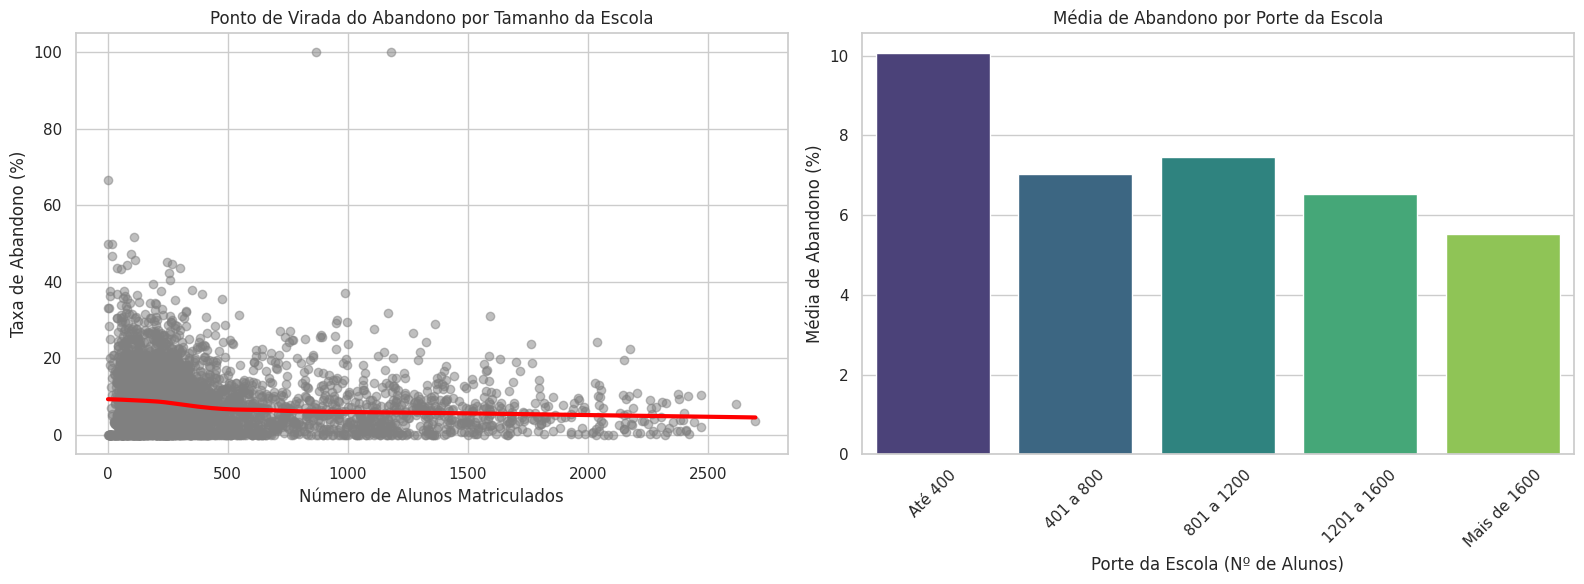

In [29]:

df_limpo = df_limpo.copy()

# Criando "baldes" (faixas) de tamanho de escolas
limites = [0, 400, 800, 1200, 1600, 3000]
nomes_faixas = ['Até 400', '401 a 800', '801 a 1200', '1201 a 1600', 'Mais de 1600']

df_limpo['Faixa_de_Tamanho'] = pd.cut(df_limpo['Quantidade_de_Matriculados_Ensino_Medio'],
                                      bins=limites, labels=nomes_faixas)

media_por_faixa = df_limpo.groupby('Faixa_de_Tamanho', observed=True)['Abandono_EM_Total'].mean().reset_index()

# Iniciando os gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.regplot(
    data=df_limpo,
    x='Quantidade_de_Matriculados_Ensino_Medio',
    y='Abandono_EM_Total',
    scatter_kws={'alpha':0.5, 'color':'gray'},
    line_kws={'color':'red', 'linewidth':3},
    lowess=True
)
plt.title('Ponto de Virada do Abandono por Tamanho da Escola')
plt.xlabel('Número de Alunos Matriculados')
plt.ylabel('Taxa de Abandono (%)')

plt.subplot(1, 2, 2)

sns.barplot(
    data=media_por_faixa,
    x='Faixa_de_Tamanho',
    y='Abandono_EM_Total',
    hue='Faixa_de_Tamanho',
    palette='viridis',
    legend=False
)
plt.title('Média de Abandono por Porte da Escola')
plt.xlabel('Porte da Escola (Nº de Alunos)')
plt.ylabel('Média de Abandono (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()